# SF Housing Intelligence Platform

## Notebook 01: Data Profiling

### Objective

The goal of this notebook is to assess the quality and structure of the San Francisco Housing Inventory dataset before building the ETL pipeline. This analysis identifies missing values, inconsistent formats, duplicate records, and potential data quality issues that must be addressed before loading the data into PostgreSQL and developing analytical dashboards and AI applications.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [5]:
df = pd.read_csv("../data/raw/Rent_Board_Housing_Inventory_20260624.csv")
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 546179 entries, 0 to 546178
Data columns (total 28 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   unique_id                            546179 non-null  int64  
 1   block_num                            546173 non-null  object 
 2   unit_count                           546177 non-null  float64
 3   case_type_name                       546179 non-null  object 
 4   submission_year                      546179 non-null  int64  
 5   block_address                        546102 non-null  object 
 6   occupancy_type                       546179 non-null  object 
 7   occupancy_or_vacancy_date            443807 non-null  object 
 8   occupancy_or_vacancy_date_year       477014 non-null  object 
 9   bedroom_count                        516071 non-null  object 
 10  bathroom_count                       516165 non-null  object 
 11  square_footag

,unique_id,block_num,unit_count,case_type_name,submission_year,block_address,occupancy_type,occupancy_or_vacancy_date,occupancy_or_vacancy_date_year,bedroom_count,bathroom_count,square_footage,monthly_rent,base_rent_includes_water_sewer,base_rent_includes_natural_gas,base_rent_includes_electricity,base_rent_includes_refuse_recycling,base_rent_includes_other_utilities,past_occupancy,vacancy_date,signature_date,occupancy_or_vacancy_date_history,year_property_built,point,analysis_neighborhood,supervisor_district,data_as_of,data_loaded_at
0,-8921002025303494677,3640,6.0,Housing Inventory - Unit information (2025),2025,3000 Block of 24TH ST,Occupied by non-owner,NaN,Year Unknown (within past 10-20 years),Two-Bedroom,One bathroom,501-750 Sq.Ft,$1001-$1250,Y,N,N,Y,NaN,NaN,NaN,2025/02/06,NaN,1900.0,POINT (-122.413261969 37.752610055),Mission,9.0,2026/06/24 01:31:02 AM,2026/06/24 06:10:41 AM
1,4926114481077084764,3640,6.0,Housing Inventory - Unit information (2025),2025,3000 Block of 24TH ST,Occupied by non-owner,1999/06/01,1999,Two-Bedroom,One bathroom,501-750 Sq.Ft,$1001-$1250,Y,N,N,Y,NaN,NaN,NaN,2025/02/06,NaN,1900.0,POINT (-122.413261969 37.752610055),Mission,9.0,2026/06/24 01:31:02 AM,2026/06/24 06:10:41 AM
2,-7607276172970613120,3640,6.0,Housing Inventory - Unit information (2025),2025,3000 Block of 24TH ST,Occupied by non-owner,2012/10/06,2012,Two-Bedroom,One bathroom,501-750 Sq.Ft,$1751-$2000,Y,N,N,Y,NaN,NaN,NaN,2025/02/06,NaN,1900.0,POINT (-122.413261969 37.752610055),Mission,9.0,2026/06/24 01:31:02 AM,2026/06/24 06:10:41 AM
3,-3082667924758429561,3643,5.0,Housing Inventory - Unit information (2025),2025,3300 Block of 24TH ST,Occupied by non-owner,2025/06/01,2025,One-Bedroom,Two bathrooms,501-750 Sq.Ft,$2251-$2500,Y,N,Y,Y,NaN,No,NaN,2025/02/06,NaN,1900.0,POINT (-122.420379791 37.752176177),Mission,9.0,2026/06/24 01:31:02 AM,2026/06/24 06:10:41 AM
4,8336260795754088004,1711,1.0,Housing Inventory - Unit information (2025),2025,1200 Block of 40TH AVE,Occupied by owner,NaN,NaN,NaN,NaN,Unknown,NaN,N,N,N,N,NaN,NaN,NaN,2025/02/06,NaN,1925.0,POINT (-122.499624472 37.763512616),Sunset/Parkside,4.0,2026/06/24 01:31:02 AM,2026/06/24 06:10:41 AM


Observations
- 546,179 rows
- 28 columns
- Mixed numeric and categorical data
- Several columns stored as object

In [13]:
profile = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values,
    "Missing": df.isna().sum().values,
    "Missing %": (
        df.isna().mean()*100
    ).round(2).values,
    "Unique": df.nunique().values
})
profile

,Column,Data Type,Missing,Missing %,Unique
0,unique_id,int64,0,0.00,546179
1,block_num,object,6,0.00,4283
2,unit_count,float64,2,0.00,195
3,case_type_name,object,0,0.00,5
4,submission_year,int64,0,0.00,5
5,block_address,object,77,0.01,7659
6,occupancy_type,object,0,0.00,4
7,occupancy_or_vacancy_date,object,102372,18.74,12662
8,occupancy_or_vacancy_date_year,object,69165,12.66,150
9,bedroom_count,object,30108,5.51,45


In [14]:
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing

vacancy_date                           525147
base_rent_includes_other_utilities     507856
occupancy_or_vacancy_date_history      465569
past_occupancy                         150922
occupancy_or_vacancy_date              102372
occupancy_or_vacancy_date_year          69165
monthly_rent                            65920
bedroom_count                           30108
bathroom_count                          30014
year_property_built                     20459
square_footage                            206
block_address                              77
analysis_neighborhood                      19
supervisor_district                        16
block_num                                   6
point                                       3
unit_count                                  2
signature_date                              0
data_as_of                                  0
unique_id                                   0
base_rent_includes_natural_gas              0
base_rent_includes_refuse_recyclin

In [17]:
for col in [
    "analysis_neighborhood",
    "occupancy_type",
    "bedroom_count",
    "bathroom_count"
]:
    print("="*40)
    print(col)
    print(df[col].value_counts(dropna=False))

analysis_neighborhood
analysis_neighborhood
Nob Hill                          50452
Tenderloin                        42278
Mission                           40564
Marina                            31535
Pacific Heights                   31291
Financial District/South Beach    24636
Russian Hill                      23486
South of Market                   22507
Western Addition                  22436
Hayes Valley                      21768
Outer Richmond                    21035
Lakeshore                         21021
Castro/Upper Market               18097
Chinatown                         17594
Inner Sunset                      15622
Sunset/Parkside                   15095
Haight Ashbury                    14500
Mission Bay                       13802
Inner Richmond                    13346
North Beach                       12487
Noe Valley                        10789
Lone Mountain/USF                  9267
Potrero Hill                       8663
Presidio Heights                   7

In [18]:
numeric_cols = df.select_dtypes(
    include=np.number
).columns

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
unique_id,546179.0,-8.775271e+15,5.321284e+18,-9.223315e+18,-4.609793e+18,-1.145576e+16,4.597562e+18,9.223363e+18
unit_count,546177.0,6.982924e+01,1.236898e+02,0.000000e+00,6.000000e+00,1.800000e+01,6.100000e+01,7.200000e+02
submission_year,546179.0,2.024268e+03,1.339091e+00,2.022000e+03,2.023000e+03,2.024000e+03,2.025000e+03,2.026000e+03
year_property_built,525720.0,1.940316e+03,3.516140e+01,1.808000e+03,1.911000e+03,1.927000e+03,1.964000e+03,2.024000e+03
supervisor_district,546163.0,4.856858e+00,2.634639e+00,1.000000e+00,3.000000e+00,5.000000e+00,7.000000e+00,1.100000e+01


In [19]:
object_cols = df.select_dtypes(
    include="object"
).columns

object_cols

Index(['block_num', 'case_type_name', 'block_address', 'occupancy_type',
       'occupancy_or_vacancy_date', 'occupancy_or_vacancy_date_year',
       'bedroom_count', 'bathroom_count', 'square_footage', 'monthly_rent',
       'base_rent_includes_water_sewer', 'base_rent_includes_natural_gas',
       'base_rent_includes_electricity', 'base_rent_includes_refuse_recycling',
       'base_rent_includes_other_utilities', 'past_occupancy', 'vacancy_date',
       'signature_date', 'occupancy_or_vacancy_date_history', 'point',
       'analysis_neighborhood', 'data_as_of', 'data_loaded_at'],
      dtype='object')

In [21]:
df["point"].head()

0    POINT (-122.413261969 37.752610055)
1    POINT (-122.413261969 37.752610055)
2    POINT (-122.413261969 37.752610055)
3    POINT (-122.420379791 37.752176177)
4    POINT (-122.499624472 37.763512616)
Name: point, dtype: object

Questions this dataset can answer
- Which neighborhoods are most affordable?
- Which neighborhoods have the most vacancies?
- Does square footage explain rent?
- How has housing inventory changed?
- Where should someone live with a fixed budget?
- Which districts need more affordable housing?

## Initial Findings

- Dataset contains 546,180 housing records.
- Several columns are stored as text rather than numeric values.
- The `monthly_rent` column appears to contain ranges instead of exact values.
- The `point` column stores geographic coordinates that can be split into latitude and longitude.
- Date columns require conversion to datetime format.
- Missing values will need to be addressed before loading the data into PostgreSQL.

### Next Steps

- Build an ETL pipeline to clean and standardize the dataset.
- Create a normalized PostgreSQL schema.
- Perform exploratory data analysis after cleaning.

In [23]:
# 1
df["monthly_rent"].value_counts(dropna=False).head(20)

# 2
df["square_footage"].value_counts(dropna=False)

# 3
df["bedroom_count"].value_counts(dropna=False)

# 4
df["bathroom_count"].value_counts(dropna=False)

# 5
df["analysis_neighborhood"].value_counts()

# 6
df["submission_year"].value_counts()

submission_year
2025    132088
2026    127948
2024    111513
2023    107886
2022     66744
Name: count, dtype: int64

In [24]:
df["monthly_rent"].value_counts(dropna=False).head(30)

monthly_rent
NaN                                  65920
$2251-$2500                          40805
$1751-$2000                          39901
$2751-$3000                          38147
$2501-$2750                          36664
$2001-$2250                          36463
$1501-$1750                          35974
$1251-$1500                          31615
$3001-$3250                          29308
$3251-$3500                          27531
$1001-$1250                          26779
$751-$1000                           18636
$3501-$3750                          17858
$3751-$4000                          16886
$501-$750                            16512
$4001-$4250                          10828
$4251-$4500                          10052
$4751-$5000                           7000
$4501-$4750                           6472
$251-$500                             6043
$5001-$5250                           3924
$7000+                                3910
$0 (no rent paid by the occupant)     357

In [25]:
df["monthly_rent"].sample(30)

227314            NaN
315600    $3001-$3250
75632     $1751-$2000
526995    $2751-$3000
74167     $3001-$3250
290429    $2251-$2500
474611    $3751-$4000
38776     $1251-$1500
208091    $3001-$3250
208476    $1251-$1500
238013    $2751-$3000
211541            NaN
56087      $751-$1000
29594     $3501-$3750
187942            NaN
271097    $2001-$2250
170011    $3251-$3500
520268    $2751-$3000
357472    $3001-$3250
112447    $1501-$1750
106923            NaN
27973     $1251-$1500
60797     $4501-$4750
506740      $501-$750
28707     $1251-$1500
290953    $2001-$2250
144711    $4001-$4250
378551    $1751-$2000
395327    $2251-$2500
540459    $2251-$2500
Name: monthly_rent, dtype: object

In [26]:
df["square_footage"].value_counts(dropna=False)

square_footage
501-750 Sq.Ft      165593
751-1000 Sq.Ft     110201
251-500 Sq.Ft      108949
1001-1250 Sq.Ft     51093
Unknown             38280
0-250 Sq.Ft         34459
1251-1500 Sq.Ft     19397
1501-1750 Sq.Ft      8959
1751-2000 Sq.Ft      3993
2001-2250 Sq.Ft      1672
2251-2500 Sq.Ft      1502
2501-2750 Sq.Ft       535
2751-3000 Sq.Ft       527
3001-3250 Sq.Ft       217
4000+ Sq.Ft           216
NaN                   206
3251-3500 Sq.Ft       184
3501-3750 Sq.Ft       125
3751-4000 Sq.Ft        70
0-250 Sq.ft             1
Name: count, dtype: int64

In [27]:
df["bedroom_count"].value_counts(dropna=False)

bedroom_count
One-Bedroom       207588
Studio            140585
Two-Bedroom       126309
NaN                30108
Three-Bedroom      29748
Four-Bedroom        6142
1                   1569
5+                  1561
2                    999
0                    605
One Bedroom          199
3                    163
Two Bedroom          145
studio               143
1 Bedroom             74
1 bedroom             41
1br                   38
3 bedroom             26
One-bedroom           18
2 bedroom             13
2br                   12
2A                    11
Garage                10
2S                     9
1A                     7
2brd                   6
Studio (sm)            6
2U                     5
2T                     5
Two-bedroom            4
3bedroom               4
1U                     4
0U                     3
1bedroom               3
1T                     2
Zero-(Studio)          2
Zero -(Studio)         2
Five-Bedroom           2
2 bedroomq             1
2AH        

In [28]:
df["bathroom_count"].value_counts(dropna=False)


bathroom_count
One bathroom                                   412283
Two bathrooms                                   59815
NaN                                             30014
Shared bathroom facilities with other units     20865
One and a half bathrooms                        10750
Three bathrooms or more                          4572
Two and a half bathrooms                         3864
1                                                2617
One Bathroom                                      529
2                                                 240
One-Bathroom                                      130
Two bathroom                                      124
0                                                  93
1.00                                               65
1 bathroom                                         64
2.5                                                52
2 bathroom                                         52
One-Bedroom                                        12
1bathroom    

In [30]:
df["analysis_neighborhood"].value_counts()

analysis_neighborhood
Nob Hill                          50452
Tenderloin                        42278
Mission                           40564
Marina                            31535
Pacific Heights                   31291
Financial District/South Beach    24636
Russian Hill                      23486
South of Market                   22507
Western Addition                  22436
Hayes Valley                      21768
Outer Richmond                    21035
Lakeshore                         21021
Castro/Upper Market               18097
Chinatown                         17594
Inner Sunset                      15622
Sunset/Parkside                   15095
Haight Ashbury                    14500
Mission Bay                       13802
Inner Richmond                    13346
North Beach                       12487
Noe Valley                        10789
Lone Mountain/USF                  9267
Potrero Hill                       8663
Presidio Heights                   7509
Twin Peaks        

In [31]:
df["occupancy_type"].value_counts(dropna=False)

occupancy_type
Occupied by non-owner    480026
Vacant                    35957
Occupied by owner         27582
Non-Residential            2614
Name: count, dtype: int64

In [32]:
df["year_property_built"].describe()

count    525720.000000
mean       1940.315978
std          35.161395
min        1808.000000
25%        1911.000000
50%        1927.000000
75%        1964.000000
max        2024.000000
Name: year_property_built, dtype: float64

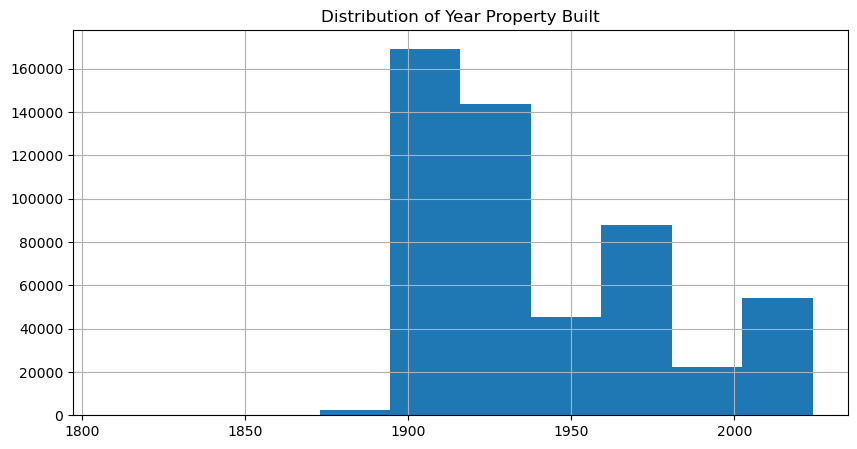

In [33]:
df["year_property_built"].hist(figsize=(10,5))
plt.title("Distribution of Year Property Built")
plt.show()

In [34]:
df["point"].head()

0    POINT (-122.413261969 37.752610055)
1    POINT (-122.413261969 37.752610055)
2    POINT (-122.413261969 37.752610055)
3    POINT (-122.420379791 37.752176177)
4    POINT (-122.499624472 37.763512616)
Name: point, dtype: object